In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.spatial import KDTree
from scipy.stats import multivariate_normal
from scipy.linalg import expm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Getting the market data

ticker = '^NSEI'  # For Nifty50
data = yf.download(ticker, start='2008-01-01', end='2026-05-31')['Close']

if isinstance(data, pd.DataFrame):
    data = data.squeeze()

data = data.dropna()
log_returns = pd.DataFrame({ticker: np.log(data / data.shift(1)).dropna()})

rets = log_returns[ticker].values
dates = log_returns.index

[*********************100%***********************]  1 of 1 completed


In [3]:
# Calculating Hurst Exponent using R/S rescaling method

def calc_hurst(ts):
    ts, N = np.asarray(ts), len(ts)
    if N < 20:
        return np.nan          # Because the number of observations has to be more than 20, Hurst exp do not work with very small sample sizes.

    lags = np.unique(np.logspace(np.log10(10), np.log10(N // 2), 10).astype(int))    # We are getting 10 equally spaced (in log scale) values between 10 and (N//2)

    log_rs, log_n = [], []     # This will store log(R/S) values and log(n) values


    for n in lags:             # We are looping through each scale

        blocks = ts[:N - N % n].reshape(-1, n)   # `N - N % n` ensures the remainder when `N/n` is removed so that we could easily create a matrix with `(N - N % n) / n` rows and n columns

        Z = np.cumsum(blocks - blocks.mean(axis=1, keepdims=True), axis=1)   # Here for each block, we subtract mean from the values to get fluctuations without mean.
                                                                             # Then we calculate the cumulative sum to see how these fluctuations behave sequentially.

        R = Z.max(axis=1) - Z.min(axis=1)  # R is range of the cumulative process of fluctuations

        S = blocks.std(axis=1, ddof=1)     # Standard deviation of fluctuations, to measure the typical fluctuation size

        valid = S > 0                      # To ensure division by zero do not happen

        if valid.any():
            log_rs.append(np.log((R[valid] / S[valid]).mean()))  # Average value of R/S across all blocks for the current scale n. We can say this is log[ mean(R/S) ]
            log_n.append(np.log(n))

    return np.polyfit(log_n, log_rs, 1)[0] if len(log_n) > 2 else np.nan  # We regress E[log(R/S)] as a function of log(n) and get the slope value

In [4]:
# Calculating Largest Lyapunov Exponent

'''
LLE is being applied over log returns and as this time series is theoretically an IID (efficient market hypothesis) and independent from the previous values, therefore LLE will always be
more than 0. The distinction between `Complete Chaos Regime` and `Boundary of Chaos and Persistence Regime` is defined using the magnitude of LLE.
'''

# We estimate Theiler so that we avoid picking two consecutive values in a time series. Theiler window is our no-go window. This is crucial for clustering in a time series data.
# We tell the KDTree algorithms to not consider values in this window.

def estimate_theiler(ts, default_n = 10):

    ts_c = ts - ts.mean()        # We remove the mean from all values to see the deviations (fluctuations), mean centered data

    var = np.var(ts_c, ddof=1)   # Finding variance of the mean centered data

    if var == 0:
        return default_n         # If there is zero variance, pick values that are `default_n` timestamps apart

    for lag in range(1, min(20, len(ts) - 1)):
        autocorrelation = np.dot(ts_c[:-lag], ts_c[lag:]) / ((len(ts) - 1) * var)
        if  autocorrelation <= 0:      # The moment autocorrelation becomes zero or negative is where the linear relationship breaks.
                                       # So now this becomes a safe zone for clustering algo to work on.
            return max(2, lag)
    return default_n


def calc_lyapunov(ts, m=3, tau=1, traj_len=10):

  # m is embedding dimension. Dimension of the vector that will represent the state space. We will use m=3 by default as this can help us capture more dimensions.
  # tau is delay in timestamps. For instance, [ x[i], x[i + tau], x[i + 2*tau], . . . , x[i + (m - 1) * tau] ]
  # traj_len is the future steps we follow

  # Delay Embedding (Taken's Theorem)

    ts = np.asarray(ts)
    emb_len = len(ts) - (m - 1) * tau   # Embedding Length = `Length of Time Series` - `Count of elements in defined state space`. This is the count of complete vectors we can build.

    if emb_len < traj_len + 5:          # To few possible vectors and the entire process is statistically useless. So we should have a good enough number of complete vectors to begin with.
        return np.nan

    X = np.array([ts[i:i + (m - 1) * tau + 1:tau] for i in range(emb_len)])  # Creating len(embedding length) number of vectors with length `(m-1) * tau`


    tree = KDTree(X)
    theiler = estimate_theiler(ts)      # Finding Theiler window for given time series

    divergence = np.zeros(traj_len)
    count     = np.zeros(traj_len, dtype=int)

    for i in range(emb_len - traj_len): # Looping over ts until we have the last usable data

        _, idxs = tree.query(X[i], k=min(20, emb_len))  # We are finding 20 nearest vectors to a given vector X[i]
        nn = next((
                j for j in idxs         # Looping over all nearest vectors found
             if abs(i - j) > theiler    # Checking if `|i - j| > W` holds true
             and
             j + traj_len < emb_len     # Only loop over data points within last usable range
                ),-1)

        if nn == -1:                    # If no nearest neighbour exists, skip this entire loop
            continue
        d     = np.linalg.norm(X[i:i + traj_len] - X[nn:nn + traj_len], axis=1)   # Compute Euclidean distance between two relevant data points

        valid = d > 1e-10               # If the distance is more than an allowed minimum value of 1e-10, only then it is considered valid

        divergence[valid] += np.log(d[valid])  # Calculating log(d0)
        count[valid]      += 1

    valid = count > 0
    if valid.sum() < 3:
        return np.nan
    return float(np.polyfit(np.arange(traj_len)[valid],
                            divergence[valid] / count[valid], 1)[0])  # Fitting a linear regression and finding it slope, which is out lambda.

In [5]:
# Calculating Sample Entropy (SampEn)

def calc_sampen(ts, m=2, r_mult=0.2):

  # ts is the time series
  # m is the 'template length' or the length of continuous data that we measure
  # r_mult is our 'tolerance level' or to say of two series are within r_mult*sigma, then we consider them

    ts, N = np.asarray(ts, dtype=float), len(ts)
    r = r_mult * ts.std(ddof=1)                   # Calculating r = r_mult * sigma(time_series)
    if r == 0:
        return np.nan

    def count_matches(dim):
        templates = np.lib.stride_tricks.sliding_window_view(ts, dim)[:-1]   # Creating sliding window templates of length 'm'
        dist = np.abs(templates[:, None] - templates[None, :]).max(axis=2)   # Computing pair-wise distance between all elements of the pairs, and take the max of it (Chebyshev distance)
        np.fill_diagonal(dist, np.inf)                                       # Removing distances of an element with itself
        return (dist <= r).sum()

    B, A = count_matches(m), count_matches(m + 1)                            # Count matching entropy series with m and m+1 lengths
    return -np.log(A / B) if B > 0 and A > 0 else np.nan                     # Return -log[A / B]

In [6]:
# Lag-1 Autocorrelation Calculation

def calc_rho(s):
    n = len(s)
    if n < 2: return np.nan
    mu = np.mean(s)
    cov = np.sum((s[:-1] - mu) * (s[1:] - mu)) / (n - 1)
    var = np.var(s, ddof=1)
    if var == 0: return np.nan
    return cov / var

In [7]:
window_h   = 200       # Window for Hurst Exponent (This is a long window because H.E. takes log-log exponent and needs larger window length.)
window_l   = 90        # Window for Lyapunov Exponent
window_s   = 90        # Window for Sample Entropy
window_a   = 90        # Window for Autocorrelation
stride     = 3         # Calculating after 5 days


res_df = pd.DataFrame(
    [{'Date':   dates[i - 1],
      'H':      calc_hurst(rets[i - window_h : i]),
      'Lyap':   calc_lyapunov(rets[i - window_l : i]),
      'SampEn': calc_sampen(rets[i - window_s: i]),
      'Rho':    calc_rho(rets[i - window_a : i])}
     for i in range(window_h, len(dates), stride)]
).set_index('Date').dropna()


Training Diagnostics
          Mean     Std  5th Pct  95th Pct
H       0.6005  0.0490   0.5191    0.6803
Lyap    0.1128  0.0144   0.0888    0.1367
SampEn  2.1942  0.4815   1.5680    3.0795
Rho     0.0481  0.0924  -0.1210    0.1900


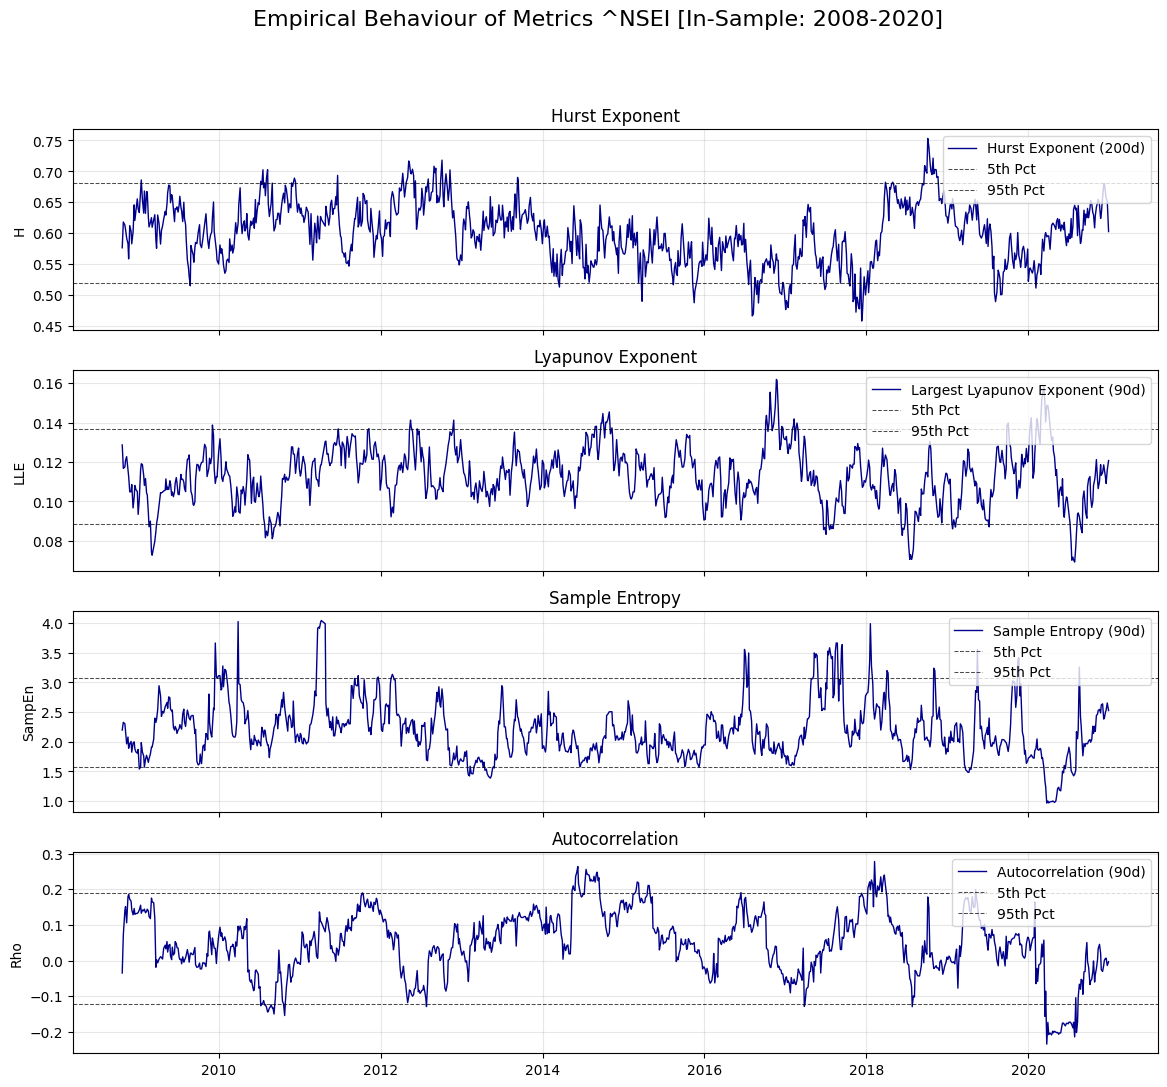

In [8]:
data_cols = ['H', 'Lyap', 'SampEn', 'Rho']

# --- Split ---

training_ends = '2020-12-31'
testing_starts = '2021-07-01'

Y_train = res_df.loc[:training_ends, data_cols]
Y_test  = res_df.loc[testing_starts:, data_cols]        # We are leaving 6 months of data as an embargo period

# --- Diagnostics: one DataFrame operation replaces the print loop ---
stats = pd.concat([Y_train.mean(), Y_train.std(),
                   Y_train.quantile(0.05), Y_train.quantile(0.95)],
                  axis=1, keys=['Mean', 'Std', '5th Pct', '95th Pct'])
print(f"\nTraining Diagnostics\n{stats.round(4).to_string()}")


res_df_is = res_df.loc[:training_ends]

fig_metrics, axes_metrics = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig_metrics.suptitle(f'Empirical Behaviour of Metrics {ticker} [In-Sample: 2008-{training_ends[:4]}]', fontsize=16)

# 1. Hurst Exponent
axes_metrics[0].plot(res_df_is.index, res_df_is['H'], label=f'Hurst Exponent ({window_h}d)', color='darkblue', linewidth=1)
axes_metrics[0].set_ylabel('H')
axes_metrics[0].set_title('Hurst Exponent')
axes_metrics[0].grid(True, alpha=0.3)
axes_metrics[0].axhline(res_df_is['H'].quantile(0.05), color='black', linestyle='--', alpha=0.7, label='5th Pct',  linewidth=0.75)
axes_metrics[0].axhline(res_df_is['H'].quantile(0.95), color='black', linestyle='--', alpha=0.7, label='95th Pct', linewidth=0.75)
axes_metrics[0].legend(loc='upper right')

# 2. Lyapunov Exponent
axes_metrics[1].plot(res_df_is.index, res_df_is['Lyap'], label=f'Largest Lyapunov Exponent ({window_s}d)', color='darkblue', linewidth=1)
axes_metrics[1].set_ylabel('LLE')
axes_metrics[1].axhline(res_df_is['Lyap'].quantile(0.05), color='black', linestyle='--', alpha=0.7, label='5th Pct',  linewidth=0.75)
axes_metrics[1].axhline(res_df_is['Lyap'].quantile(0.95), color='black', linestyle='--', alpha=0.7, label='95th Pct', linewidth=0.75)
axes_metrics[1].set_title('Lyapunov Exponent')
axes_metrics[1].legend(loc='upper right')
axes_metrics[1].grid(True, alpha=0.3)

# 3. Sample Entropy
axes_metrics[2].plot(res_df_is.index, res_df_is['SampEn'], label=f'Sample Entropy ({window_s}d)', color='darkblue', linewidth=1)
axes_metrics[2].set_ylabel('SampEn')
axes_metrics[2].axhline(res_df_is['SampEn'].quantile(0.05), color='black', linestyle='--', alpha=0.7, label='5th Pct',  linewidth=0.75)
axes_metrics[2].axhline(res_df_is['SampEn'].quantile(0.95), color='black', linestyle='--', alpha=0.7, label='95th Pct', linewidth=0.75)
axes_metrics[2].set_title('Sample Entropy')
axes_metrics[2].legend(loc='upper right')
axes_metrics[2].grid(True, alpha=0.3)

# 4. Autocorrelation
axes_metrics[3].plot(res_df_is.index, res_df_is['Rho'], label=f'Autocorrelation ({window_s}d)', color='darkblue', linewidth=1)
axes_metrics[3].set_ylabel('Rho')
axes_metrics[3].axhline(res_df_is['Rho'].quantile(0.05), color='black', linestyle='--', alpha=0.7, label='5th Pct',  linewidth=0.75)
axes_metrics[3].axhline(res_df_is['Rho'].quantile(0.95), color='black', linestyle='--', alpha=0.7, label='95th Pct', linewidth=0.75)
axes_metrics[3].set_title('Autocorrelation')
axes_metrics[3].legend(loc='upper right')
axes_metrics[3].grid(True, alpha=0.3)

plt.show()

In [9]:
# State0: Equilibrium or Mean Reversion:  [Hurst < 0.49] (This tells negative correlation or that the process is fighting against its own motion.)
#                                         [Lyapunov < 0.10] (This tells if the distance shrinks exponentially. Ideally for stable markets LLE <= 0. But we do not observe that.)
#                                         [SampEn < 2.5] (This tells that there is less new incoming information in the system and the movement is mostly stable.)
#                                         [Autocorr < 0] (This tells that prices fall back to structural mean or stable equilibrium.)



# State1: Complete Chaos:  [Hurst = (0.40, 0.60)] (This signify a random walk. There remains no predictability.)
#                          [Lyapunov > 0.13] (This indicates an explosive behaviour.)
#                          [SampEn > 2.5] (This indicates an increase in incoming information.)
#                          [Autocorr = (-0.1, 0.1)] (This indicates lack of linear memory.)



# State3: Edge of Chaos:  [Hurst > 0.51] (This tells positive correlation or the presence of momentum.)
#                         [Lyapunov < 0.10] (This signify an increasing distance but not explosively.)
#                         [SampEn = (1.9, 2.3)] (This tells that information is arriving, but not too fast or not too much quickly.)
#                         [Autocorr > 0] (This indicates the presence of short-term momentum)

In [10]:
def classify_regimes(df):
    H, Lyap, SampEn, Rho = df['H'], df['Lyap'], df['SampEn'], df['Rho']

    s0 = (
        (H < 0.49).astype(int) +
        (Lyap < 0.10).astype(int) +
        (SampEn < 2.5).astype(int) +              # tightened, no longer overlaps State2's lower bound
        (Rho < 0).astype(int)
    )

    s1 = (
        ((H >= 0.40) & (H <= 0.60)).astype(int) +
        (Lyap > 0.13).astype(int) +
        (SampEn > 2.5).astype(int) +
        ((Rho > -0.1) & (Rho < 0.1)).astype(int)
    )

    s2 = (
        (H > 0.51).astype(int) +
        ((Lyap >= 0.10) & (Lyap <= 0.12)).astype(int) +   # now a distinct band, not "<0.12"
        ((SampEn >= 1.9) & (SampEn <= 2.3)).astype(int) + # now a distinct band, not "1.5–2.8"
        (Rho > 0).astype(int)
    )

    scores = pd.DataFrame({'State0': s0, 'State1': s1, 'State2': s2}, index=df.index)
    regime = scores[['State1', 'State2', 'State0']].idxmax(axis=1)
    return scores, regime

In [11]:
scores_df, regime_series = classify_regimes(res_df_is)
res_df_is = res_df_is.assign(
    Score_State0=scores_df['State0'],
    Score_State1=scores_df['State1'],
    Score_State2=scores_df['State2'],
    Regime=regime_series
)

print(res_df_is[['H', 'Lyap', 'SampEn', 'Rho', 'Regime']].head(10))
print("\nRegime distribution:")
print(res_df_is['Regime'].value_counts(normalize=True).mul(100).round(2))

                   H      Lyap    SampEn       Rho  Regime
Date                                                      
2008-10-22  0.576207  0.128648  2.197225 -0.034993  State1
2008-10-27  0.617926  0.116753  2.327278  0.072261  State2
2008-11-03  0.613000  0.117494  2.302585  0.140645  State2
2008-11-06  0.605923  0.120846  2.178532  0.151425  State2
2008-11-11  0.592003  0.122701  1.963610  0.105863  State2
2008-11-17  0.583002  0.116078  2.079442  0.178870  State2
2008-11-20  0.558250  0.112742  1.890850  0.185592  State2
2008-11-25  0.612158  0.104859  1.966113  0.171974  State2
2008-12-01  0.602933  0.104959  2.005334  0.166488  State2
2008-12-04  0.582603  0.108577  1.824549  0.142564  State2

Regime distribution:
Regime
State2    66.40
State1    25.13
State0     8.48
Name: proportion, dtype: float64


In [12]:
def enforce_min_duration(regime_series, min_obs=4):
    regime = regime_series.copy()
    block_id = regime.ne(regime.shift()).cumsum()
    block_sizes = regime.groupby(block_id).transform('size')

    short_blocks = block_sizes < min_obs
    regime[short_blocks] = np.nan
    regime = regime.ffill().bfill()   # bfill catches any leading NaNs ffill can't reach
    return regime

res_df_is['Regime_smoothed'] = enforce_min_duration(res_df_is['Regime'], min_obs=4)

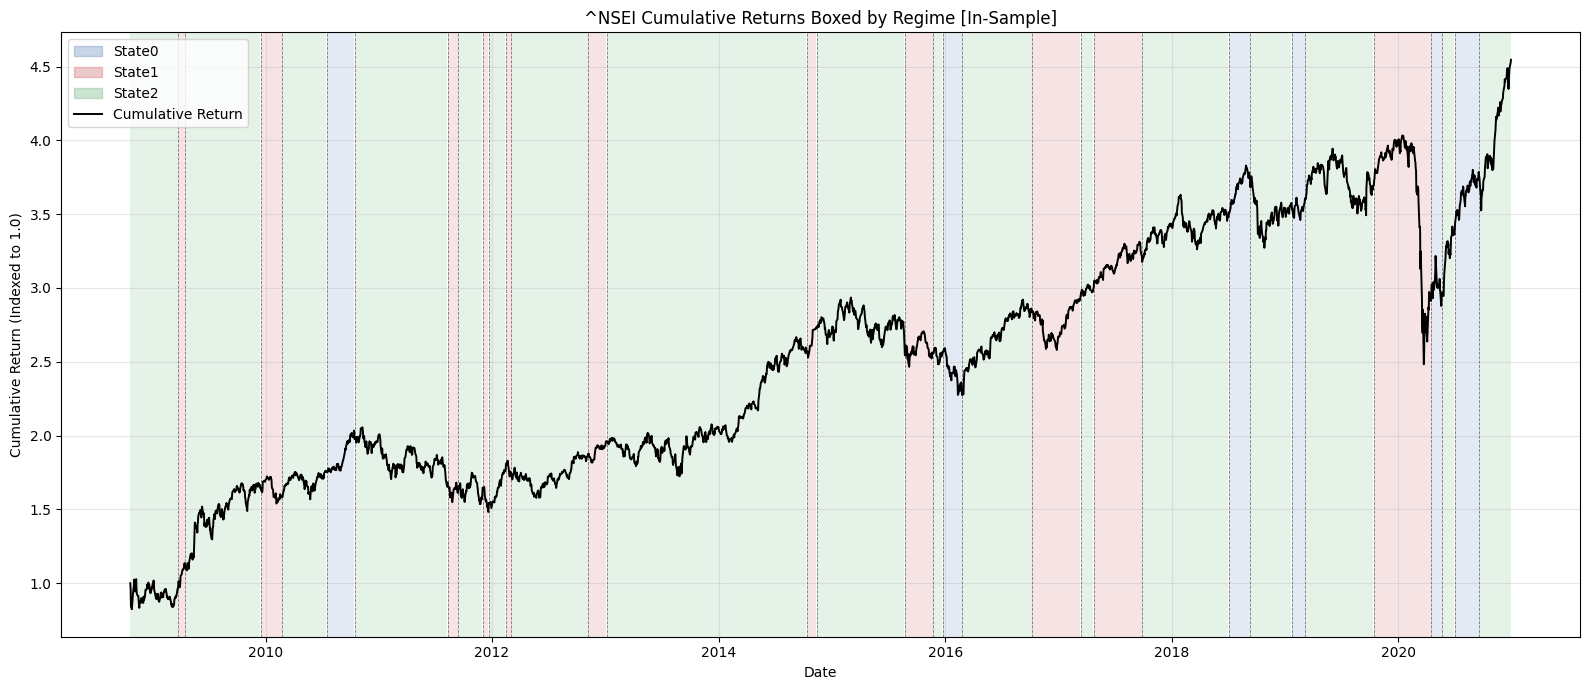

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 1. Compute cumulative returns aligned to the res_df_is date range ---
plot_returns = log_returns[ticker].loc[res_df_is.index[0] : res_df_is.index[-1]]
cum_returns = np.exp(plot_returns.cumsum())
cum_returns = cum_returns / cum_returns.iloc[0]   # index to 1.0

# --- 2. Define regime colors ---
regime_colors = {
    'State0': '#4C72B0',   # blue  — Equilibrium / Mean Reversion
    'State1': '#C44E52',   # red   — Complete Chaos
    'State2': '#55A868',   # green — Edge of Chaos
}

# --- 3. Identify contiguous regime blocks ---
# res_df_is['Regime'] is sampled at stride intervals, not daily.
# We forward-fill it onto the daily cum_returns index so the
# shading aligns with the actual cumulative return line.
regime_daily = res_df_is['Regime_smoothed'].reindex(cum_returns.index, method='ffill')
regime_daily = regime_daily.bfill()   # fill any leading NaNs before first regime obs

# Find where regime changes — these become block boundaries
change_points = regime_daily.ne(regime_daily.shift()).cumsum()
blocks = regime_daily.groupby(change_points).agg(
    regime=('first' if False else (lambda s: s.iloc[0]))
)

# Build (start_date, end_date, regime) tuples for each contiguous block
block_bounds = []
for _, grp in regime_daily.groupby(change_points):
    block_bounds.append((grp.index[0], grp.index[-1], grp.iloc[0]))

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(16, 7))

# Shade each contiguous regime block
for start, end, regime in block_bounds:
    ax.axvspan(start, end, color=regime_colors[regime], alpha=0.15, lw=0)

# Draw vertical lines at every regime transition
for i in range(1, len(block_bounds)):
    transition_date = block_bounds[i][0]
    ax.axvline(transition_date, color='black', linestyle='--',
               linewidth=0.6, alpha=0.5)

# Plot the cumulative return line on top
ax.plot(cum_returns.index, cum_returns.values, color='black',
       linewidth=1.4, label='Cumulative Return', zorder=5)

# --- 5. Legend (custom patches for shaded regions) ---
legend_patches = [
    mpatches.Patch(color=regime_colors[r], alpha=0.3, label=r)
    for r in regime_colors
]
ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0],
         loc='upper left', frameon=True)

ax.set_title(f'{ticker} Cumulative Returns Boxed by Regime [In-Sample]')
ax.set_ylabel('Cumulative Return (Indexed to 1.0)')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
state_map = {'State0': 0, 'State1': 1, 'State2': 2}

# --- Classify training data using the same rule-based classifier ---
train_scores, train_regime = classify_regimes(Y_train)
train_regime_smoothed = enforce_min_duration(train_regime, min_obs=4)

# --- Convert smoothed training regimes to integer state codes ---
train_labels_int = train_regime_smoothed.map(state_map).astype(int).values

print("Training regime distribution:")
print(train_regime_smoothed.value_counts(normalize=True).mul(100).round(2))

Training regime distribution:
State2    72.45
State1    18.67
State0     8.88
Name: proportion, dtype: float64


In [15]:
test_scores, test_regime = classify_regimes(Y_test)
test_regime_smoothed = enforce_min_duration(test_regime, min_obs=4)

In [16]:
# --- Calibrate regime-conditional return and volatility from training data ---
train_rets = log_returns[ticker].loc[Y_train.index]
global_mu, global_vol = train_rets.mean(), train_rets.std()

mu_estimates, vol_estimates = [], []
for state_int in range(3):
    mask   = train_labels_int == state_int
    rets_k = train_rets.loc[Y_train.index[mask]]
    sufficient = len(rets_k) >= 20

    mu_estimates.append(rets_k.mean() if sufficient else global_mu)
    vol_estimates.append(rets_k.std()  if sufficient else global_vol)

mu_estimates  = np.array(mu_estimates)
vol_estimates = np.array(vol_estimates)

print("mu_estimates  (State0, State1, State2):", mu_estimates.round(6))
print("vol_estimates (State0, State1, State2):", vol_estimates.round(6))
print("\nTraining observation counts per state:")
for state_int in range(3):
    print(f"  State{state_int}: {(train_labels_int == state_int).sum()}")

mu_estimates  (State0, State1, State2): [-0.000294  0.000521  0.000805]
vol_estimates (State0, State1, State2): [0.009018 0.014488 0.013096]

Training observation counts per state:
  State0: 88
  State1: 185
  State2: 718


In [17]:
# Dynamic Portfolio Allocation & Backtest (Rule-Based Regimes)

# --- Convert smoothed test regimes to integer state codes ---
test_labels_int = test_regime_smoothed.map(state_map).astype(int).values

T_len = len(Y_test)
weights = np.zeros(T_len)
target_vol = 0.010  # Daily target volatility

for t in range(T_len):
    state = test_labels_int[t]

    # Regime-conditional return and volatility — looked up directly,
    # not probability-weighted, since the regime is now a hard label
    E_mu  = mu_estimates[state]
    E_var = vol_estimates[state] ** 2
    if E_var < 1e-10:
        E_var = 1e-10
    E_daily_vol = np.sqrt(E_var)

    # Instead of zeroing out when E_mu is negative, scale down but stay partially invested


    w_myopic = (target_vol / E_daily_vol) * np.sign(E_mu)

    # State1 (Chaos) hedge: continuous, not delta-based, since the
    # label is now deterministic rather than a smoothly evolving
    # probability. We hedge for the full duration the regime is active.
    hedge_flag = 1.0 if state == 1 else 0.0

    hedge_sensitivity   = -0.75   # Calibrated to give desired drawdown protection
    myopic_sensitivity  =  1.50    # Calibrated to catch up when hedge is not needed

    w_myopic = myopic_sensitivity * w_myopic
    w_hedge  = hedge_sensitivity * hedge_flag

    weights[t] = np.clip(w_myopic + w_hedge, 0.00, 1.00)


# --- Build daily weights and backtest (unchanged from before) ---
weights_series = pd.Series(weights, index=Y_test.index)

all_test_returns = log_returns[ticker].loc[
    Y_test.index[0] : Y_test.index[-1]
].dropna()

weights_daily = weights_series.reindex(
    all_test_returns.index, method='ffill'
).fillna(0)

strategy_rets = weights_daily.shift(1) * all_test_returns
strategy_rets = strategy_rets.dropna()
bnh_rets = all_test_returns.loc[strategy_rets.index]

cum_strat = np.exp(np.cumsum(strategy_rets))
cum_bnh   = np.exp(np.cumsum(bnh_rets))

cum_strat = cum_strat / cum_strat.iloc[0]
cum_bnh   = cum_bnh   / cum_bnh.iloc[0]


# --- Performance Summary ---
ann_ret_strat = strategy_rets.mean() * 252
ann_ret_bnh   = bnh_rets.mean() * 252

ann_vol_strat = strategy_rets.std() * np.sqrt(252)
ann_vol_bnh   = bnh_rets.std() * np.sqrt(252)

ann_sharpe_strat = ann_ret_strat / ann_vol_strat if ann_vol_strat != 0 else 0
ann_sharpe_bnh   = ann_ret_bnh   / ann_vol_bnh   if ann_vol_bnh   != 0 else 0

mdd_strat = (cum_strat / cum_strat.cummax() - 1.0).min()
mdd_bnh   = (cum_bnh   / cum_bnh.cummax()   - 1.0).min()

calmar_strat = ann_ret_strat / abs(mdd_strat) if mdd_strat != 0 else 0
calmar_bnh   = ann_ret_bnh   / abs(mdd_bnh)   if mdd_bnh   != 0 else 0

# Regime distribution from the rule-based labels directly
dist = test_regime_smoothed.value_counts(normalize=True) * 100

print("\n" + "="*60)
print(f"{'Performance Summary [Out-of-Sample: Rule-Based Regimes]':^60}")
print("="*60)
print(f"{'Metric':<25} | {'Strategy':<15} | {'Buy & Hold':<15}")
print("-" * 60)
print(f"{'Annualised Return':<25} | {ann_ret_strat:>14.2%} | {ann_ret_bnh:>14.2%}")
print(f"{'Annualised Sharpe':<25} | {ann_sharpe_strat:>14.2f} | {ann_sharpe_bnh:>14.2f}")
print(f"{'Max Drawdown':<25} | {mdd_strat:>14.2%} | {mdd_bnh:>14.2%}")
print(f"{'Calmar Ratio':<25} | {calmar_strat:>14.2f} | {calmar_bnh:>14.2f}")
print("=" * 60)

print("\nOut-of-Sample Regime Distribution:")
for state, pct in dist.items():
    print(f"  {state}: {pct:.2f}%")

if dist.get('State1', 0.0) > 80.0:
    print("\n[DIAGNOSTIC WARNING] State1 (Chaos) dominating above 80%.")
    print("Checking early test sample metrics:")
    print(Y_test.head(10))


  Performance Summary [Out-of-Sample: Rule-Based Regimes]   
Metric                    | Strategy        | Buy & Hold     
------------------------------------------------------------
Annualised Return         |          9.49% |          8.74%
Annualised Sharpe         |           0.83 |           0.63
Max Drawdown              |        -15.89% |        -17.23%
Calmar Ratio              |           0.60 |           0.51

Out-of-Sample Regime Distribution:
  State2: 71.53%
  State1: 21.53%
  State0: 6.93%


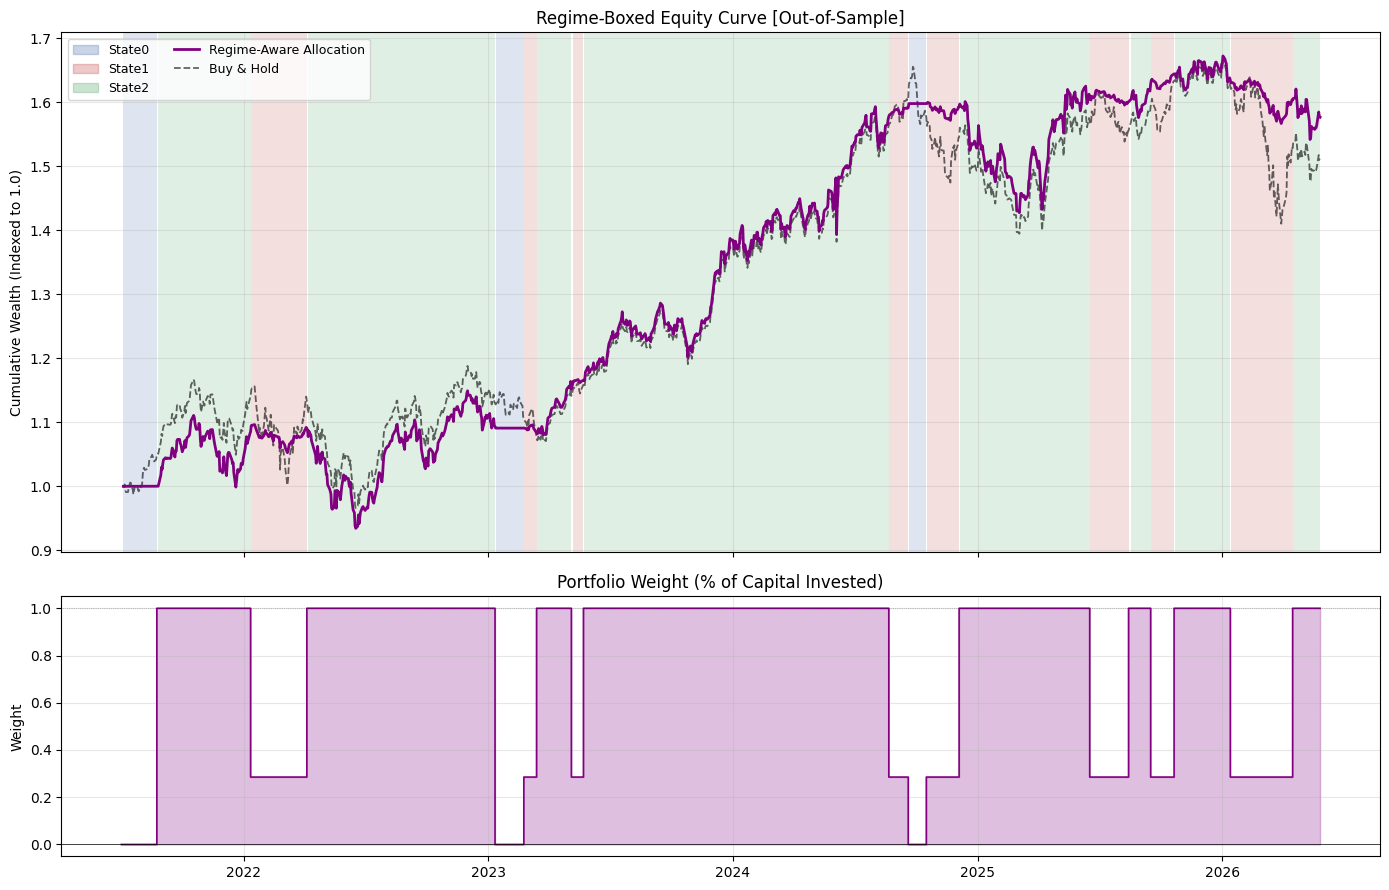

In [18]:
regime_colors = {'State0': '#4C72B0', 'State1': '#C44E52', 'State2': '#55A868'}

fig, axes = plt.subplots(
    2, 1, figsize=(14, 9),
    gridspec_kw={'height_ratios': [2, 1]}, sharex=True
)

# ---------------------------------------------------------
# TOP PANEL: Regime-shaded background + cumulative wealth
# ---------------------------------------------------------

# Build daily regime labels (forward/back-filled to match the daily index)
regime_daily = test_regime_smoothed.reindex(
    cum_strat.index, method='ffill'
).bfill()

# Shade contiguous regime blocks
change_points = regime_daily.ne(regime_daily.shift()).cumsum()
for _, grp in regime_daily.groupby(change_points):
    axes[0].axvspan(grp.index[0], grp.index[-1],
                    color=regime_colors[grp.iloc[0]], alpha=0.18, lw=0)

# Plot equity curves on top of the shading
axes[0].plot(cum_strat.index, cum_strat, label='Regime-Aware Allocation',
            color='purple', linewidth=2, zorder=5)
axes[0].plot(cum_bnh.index, cum_bnh, label='Buy & Hold',
            color='black', alpha=0.6, linestyle='--', linewidth=1.3, zorder=4)

# Legend: regime patches + line labels combined
regime_patches = [mpatches.Patch(color=c, alpha=0.3, label=s)
                  for s, c in regime_colors.items()]
line_handles, line_labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=regime_patches + line_handles,
              labels=list(regime_colors.keys()) + line_labels,
              loc='upper left', ncol=2, fontsize=9)

axes[0].set_title('Regime-Boxed Equity Curve [Out-of-Sample]')
axes[0].set_ylabel('Cumulative Wealth (Indexed to 1.0)')
axes[0].grid(True, alpha=0.3)

# ---------------------------------------------------------
# BOTTOM PANEL: Portfolio weight over time
# ---------------------------------------------------------

axes[1].fill_between(weights_daily.index, 0, weights_daily.values,
                     color='purple', alpha=0.25, step='pre')
axes[1].plot(weights_daily.index, weights_daily.values,
            color='purple', linewidth=1.2, drawstyle='steps-pre')

axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axhline(1, color='black', linewidth=0.5, linestyle=':', alpha=0.4)
axes[1].set_title('Portfolio Weight (% of Capital Invested)')
axes[1].set_ylabel('Weight')
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()